Saving student.csv to student (1).csv
RMSE: 2.16
R2 Score: 0.99
Enter study hours: 6
Predicted Marks: 78.59


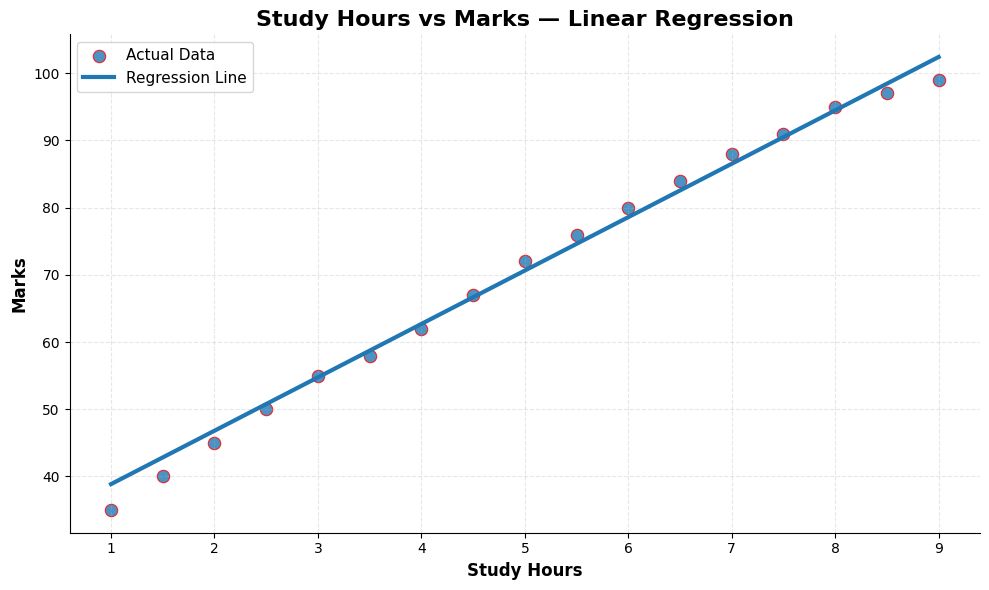

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# Upload CSV file
upload = files.upload()

# Read dataset
df = pd.read_csv("student.csv")

# Features and target
x = df[["Study_Hours"]]
y = df["Marks"]


# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)


# Create and train model
model = LinearRegression()
model.fit(x_train, y_train)


# Prediction
y_pred = model.predict(x_test)


# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))


# User input
hours = float(input("Enter study hours: "))

prediction = model.predict(
    pd.DataFrame({"Study_Hours": [hours]})
)

print("Predicted Marks:", round(prediction[0], 2))

# --------------------------------
#  LINEAR_REGRESSION PLOT
# --------------------------------

# Sort X values
x_sorted = np.sort(x["Study_Hours"].values)

# Predict using sorted X
y_sorted_pred = model.predict(
    pd.DataFrame({"Study_Hours": x_sorted})
)

plt.figure(figsize=(10, 6))

# Actual data
plt.scatter(
    x["Study_Hours"],
    y,
    s=80,
    alpha=0.8,
    edgecolors="red",
    linewidths=0.8,
    label="Actual Data"
)

# Regression line
plt.plot(
    x_sorted,
    y_sorted_pred,
    linewidth=3,
    label="Regression Line"
)

# Title
plt.title(
    "Study Hours vs Marks — Linear Regression",
    fontsize=16,
    fontweight="bold"
)

# Labels
plt.xlabel(
    "Study_Hours",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Marks",
    fontsize=12,
    fontweight="bold"
)

# Grid
plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend(
    fontsize=11
)
ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Model Accuracy: 100.0 %
Enter study hours: 4
Predicted Result: Fail
Pass Probability: 49.25 %


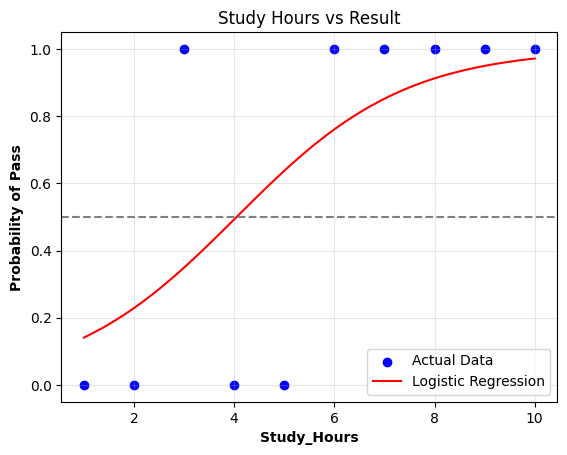

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Test model
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# User input
hours = float(input("Enter study hours: "))

prediction = model.predict([[hours]])
probability = model.predict_proba([[hours]])

if prediction[0] == 1:
    print("Predicted Result: Pass")
else:
    print("Predicted Result: Fail")

print("Pass Probability:", round(probability[0][1] * 100, 2), "%")


# -------------------------------
# LOGISTIC_REGRESSION PLOT
# -------------------------------

# Create values for smooth curve
hours_range = np.linspace(1, 10, 100).reshape(-1, 1)

# Get probability of passing
pass_probability = model.predict_proba(hours_range)[:, 1]

# Plot actual data
plt.scatter(X, y, color="blue", label="Actual Data")

# Plot logistic regression curve
plt.plot(
    hours_range,
    pass_probability,
    color="red",
    label="Logistic Regression"
)

# Decision threshold
plt.axhline(0.5, color="gray", linestyle="--")

# Labels
plt.xlabel(
    "Study_Hours",
    fontweight="bold"
)
plt.ylabel(
    "Probability of Pass",
    fontweight="bold")
plt.title("Study Hours vs Result")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()